In [1]:
#MakeMore Part3开启！
#这一部分和part2那样新开一个notebook不太一样，andrej会直接在part2的基础上继续添加东西
#我们在前面三个部分已经完整学习了神经网络的结构，而我们后面的目标就是优化他们
#直接开始吧

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
#环境导入，和之前的环境是一样的，前两行是torch，后两行是画图工具

In [3]:
words=open("names.txt","r").read().splitlines()
words[:3]
#还是一样导入words

['emma', 'olivia', 'ava']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
vocab_size=len(itos)
#还是一样建立字符数字表
#只不过直接生成好vocab_size

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#构建训练集，验证集，测试集
#直接复制过来就好
block_size=3

def build_dataset(words,block_size):#依据words构建数据集的函数
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2],block_size)#80%~90%
Xte, Yte = build_dataset(words[n2:],block_size)#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [7]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:27.8817
  10000/ 200000:2.8138
  20000/ 200000:2.5218
  30000/ 200000:2.7874
  40000/ 200000:2.0334
  50000/ 200000:2.6237
  60000/ 200000:2.3289
  70000/ 200000:2.0826
  80000/ 200000:2.2784
  90000/ 200000:2.2252
 100000/ 200000:2.0428
 110000/ 200000:2.3121
 120000/ 200000:2.0570
 130000/ 200000:2.4546
 140000/ 200000:2.2233
 150000/ 200000:2.1551
 160000/ 200000:2.0597
 170000/ 200000:1.7981
 180000/ 200000:2.0194
 190000/ 200000:1.7459


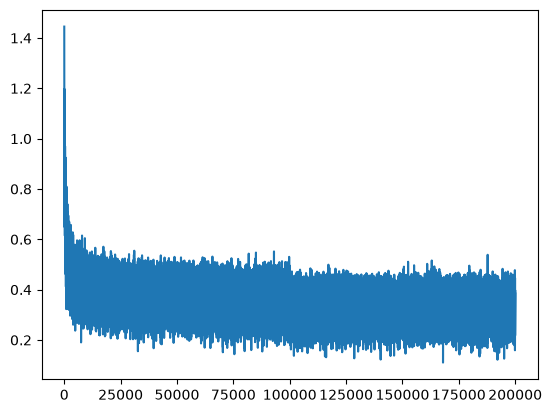

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.1267659664154053
val 2.1697638034820557


In [10]:
#采样部分，和之前是一样的，只不过我们不用多层神经网络
g = torch.Generator().manual_seed(2147483647+10)#换个种子

for i in range(20):#生成20个名字
    context=[0]*block_size#上下文。由于我们所有名字的开头全部都是一串点，所以我们可以直接用这个
    out=[]#输出

    while True:#用循环来生成姓名，直到出现'.'
        emb = C[torch.tensor([context])] 
        embcat = emb.view(1, -1) 
        h = torch.tanh(embcat @ W1 + b1) 
        logits = h @ W2 + b2 # (N, vocab_size)
        probs=F.softmax(logits,dim=1)#loss的计算用的是cross_entropy，现在用softmax计算probs
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()#根据概率输出词汇
        context=context[1:]+[ix]
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(s for s in out))

carlah.
amorie.
khirmin.
rey.
cassanden.
jazhubedah.
sart.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jore.
quint.
salin.
alianni.
wazthoniearyxi.
jace.
pirran.
eddeci.


In [11]:
#我们现在要改进我们的神经网络
#所以第一步就是：先看看他有什么问题
#首先我们会发现：我们一开始的loss出奇的高
#我们来预估一下如果一个均匀分布的loss是多少
#loss是概率的负对数似然
#所以就是
-torch.tensor(1.0/27.0).log()

tensor(3.2958)

In [12]:
#所以其实我们的loss一开始能到20多是完全没有道理的
#很可能是因为我们的一开始随机出来的参数导致了非常大的偏差
#我们用一个直观的例子
logits=torch.tensor([0.0,0.0,0.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
probs,loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [13]:
#这就是均匀分布出来的loss，当我们调大某个值

#调大错误答案
logits=torch.tensor([0.0,5.0,0.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
print("错误情况：",loss)

#调大正确答案
logits=torch.tensor([0.0,0.0,5.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
print("正确情况：",loss)

错误情况： tensor(5.0200)
正确情况： tensor(0.0200)


In [14]:
#可以看到差距非常巨大

In [15]:
#所以我们回过头来看看一开始为什么会出现这种情况
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

    break#直接break去观察logits

总参数量：11897
      0/ 200000:27.8817


In [16]:
#21，非常高
#我们来观察下具体的logits
logits[0]

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

In [17]:
#可以看到我们会出现一些非常大的数字，甚至有不少超过10的，那么我们的loss直接打到20多的数值也就不奇怪了

In [18]:
#我们思考一下为什么会出现这个问题：
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True
#这是我们的神经网络
#只有这里涉及到了randn的赋值
#我们先来看看这里会生成什么样的数值
C[0]

总参数量：11897


tensor([ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
         0.0791,  0.9046], grad_fn=<SelectBackward0>)

In [19]:
#其实还好，对吧？
#这里会按照正态分布在0附近进行分布
#但是在这个过程中会涉及好几次乘法加法
#于是这种值会逐渐累加导致最后变得非常夸张
#所以我们的第一个思路就是：神经网络在初始化的时候缩放的小一些

g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#隐藏层
b1 = torch.randn(n_hidden,                     generator=g)#隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1#激活层
b2 = torch.randn(vocab_size,                   generator=g)*0#激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [20]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:4.2326
  10000/ 200000:2.1403
  20000/ 200000:2.4720
  30000/ 200000:2.5577
  40000/ 200000:2.0154
  50000/ 200000:2.4307
  60000/ 200000:2.3385
  70000/ 200000:2.0680
  80000/ 200000:2.2665
  90000/ 200000:2.1172
 100000/ 200000:1.9299
 110000/ 200000:2.0630
 120000/ 200000:1.8901
 130000/ 200000:2.3980
 140000/ 200000:2.2826
 150000/ 200000:2.1250
 160000/ 200000:1.8469
 170000/ 200000:1.7627
 180000/ 200000:1.9119
 190000/ 200000:1.8235


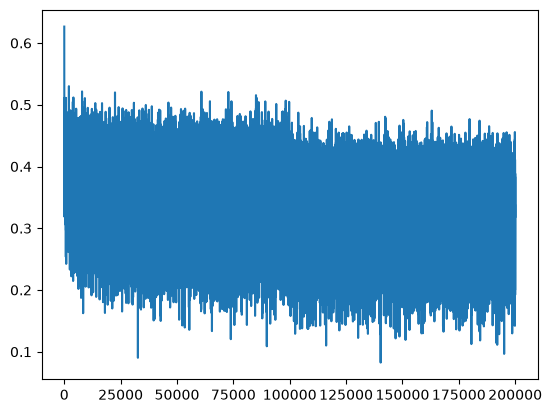

In [21]:
plt.plot(lossi)

In [22]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0681495666503906
val 2.132511854171753


In [23]:
#loss有微弱的下降
#并且我们的训练曲线不再是“曲棍球棒”形状了
#也就是说我们跳过了一开始loss急剧下降的压缩阶段

In [24]:
#好的接下来，优化完了这个神经网络，我们可以再看一下更深层的东西：h
#我们把这个h单独拎出来
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#隐藏层
b1 = torch.randn(n_hidden,                     generator=g)#隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1#激活层
b2 = torch.randn(vocab_size,                   generator=g)*0#激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

h

总参数量：11897
      0/ 200000:4.2326


tensor([[ 0.8100, -0.8997, -0.9993,  ..., -0.9097, -1.0000,  1.0000],
        [-1.0000, -0.9571, -0.7145,  ...,  0.4898,  0.9090,  0.9937],
        [ 0.9983, -0.3340,  1.0000,  ...,  0.9443,  0.9905,  1.0000],
        ...,
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000],
        [-1.0000, -0.4385, -0.8882,  ..., -0.3316,  0.9995,  1.0000],
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000]],
       grad_fn=<TanhBackward0>)

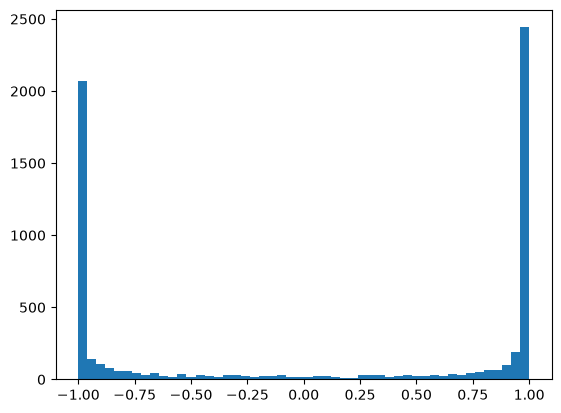

In [25]:
#我们会发现一个问题：就是h里有很多的值是1或-1或者非常接近这两个值
plt.hist(h.view(-1).tolist(),50);#这个可以生成h的直方图

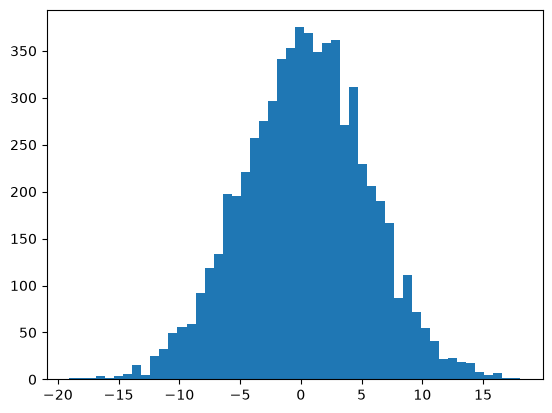

In [26]:
#这个是不是很直观，h的分布非常不健康
#所以我们来看看k接收的输入hpreact长什么样
plt.hist(hpreact.view(-1).tolist(),50);

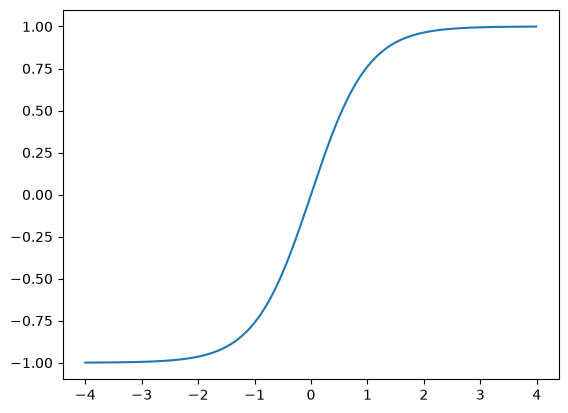

In [27]:
#其实还好，是吧？基本符合正态分布，因为我们之前就是用正态分布生成的神经网络
#但是hpreact到h的计算是tanh
#还记得tanh长什么样子吗？
import math
ii=[]
tanh=[]
for i in range(-400,400,1):
    tanh.append(math.tanh(i/100))
    ii.append(i/100)

plt.plot(ii,tanh)

In [28]:
#这个是tanh的函数曲线
#我们可以发现：大概在3左右tanh就已经非常逼近1了
#所以当h接收了hpreact之后就非常容易出现这种数值过大或者过小导致精度丢失的问题

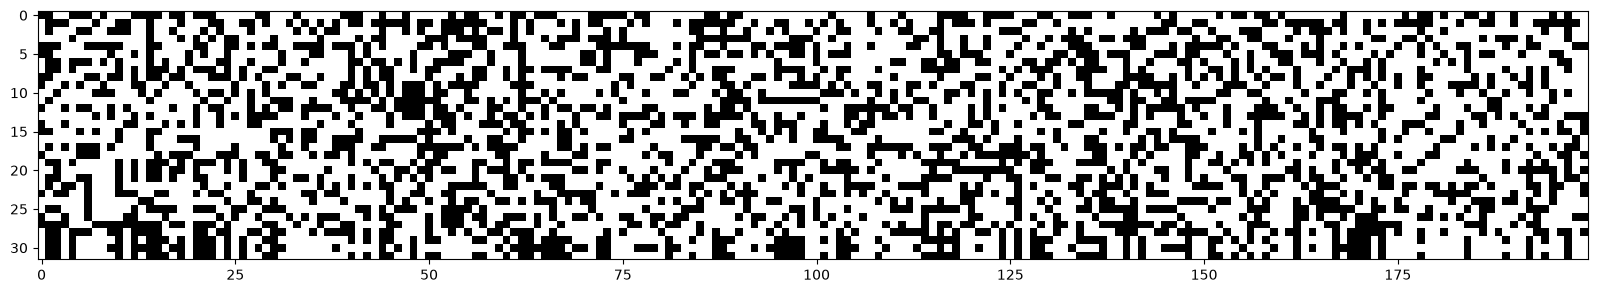

In [29]:
#那么这个会有什么问题呢？
#回忆一下micrograd
#我们的调整方式是梯度下降法。
#但是我们来观察一下这个tanh函数接近1之后的梯度长什么样：
#几乎是0
#也就是说：当我们的h趋近于1或者-1的时候：我们的grad调不动他了
#甚至可能会出现grad卡死的情况：因为精度不够导致梯度直接被看成了0
#我们来观察一下有多少的h处于这种极端区间（绝对值>0.99）
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')#在这里符合最前面那个标准的会显示为白色

In [30]:
#可以发现几乎一大半的参数都显示为超过0.99
#这就是大麻烦：这种神经元无法进行梯度更新，也就是说会变成“死亡神经元”
#这种神经元学不到东西 
#同时这种情况也很可能出现在训练过程中：
#因为训练过程如果步长设置的太大的话，可能会导致我们的h一脚直接踏到了“死亡区”
#这就是训练中的“脑损伤”
#有时候出现这种情况就会发现有的神经元从来没有被激活过，也就是再也不该变了
#这个时候这个神经元就“死亡”了

#所以这样看其实有个很简单的方法：我们直接把之前的参数初始值再调低一点就可以了


g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*0.2      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

h

总参数量：11897
      0/ 200000:3.3135


tensor([[ 0.5503, -0.1064, -0.6658,  ..., -0.3477, -0.9756,  0.8880],
        [-0.9081, -0.1924, -0.1833,  ...,  0.0494,  0.4942,  0.4397],
        [ 0.8016,  0.1173,  0.8237,  ...,  0.2890,  0.6476,  0.8827],
        ...,
        [-0.9190,  0.5208, -0.0346,  ..., -0.0830,  0.8660,  0.8849],
        [-0.9362,  0.0930, -0.2810,  ..., -0.1260,  0.7874,  0.9102],
        [-0.9190,  0.5208, -0.0346,  ..., -0.0830,  0.8660,  0.8849]],
       grad_fn=<TanhBackward0>)

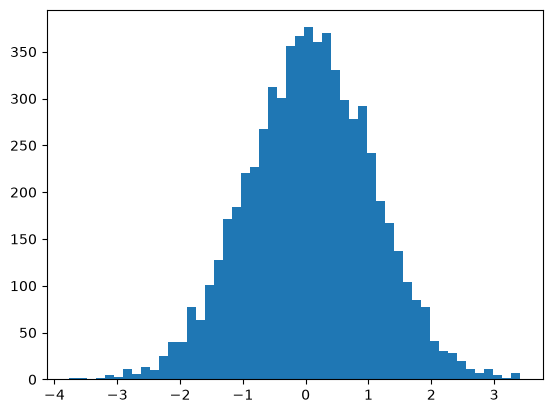

In [31]:
#这样是不是好了很多？
plt.hist(hpreact.view(-1).tolist(),50);

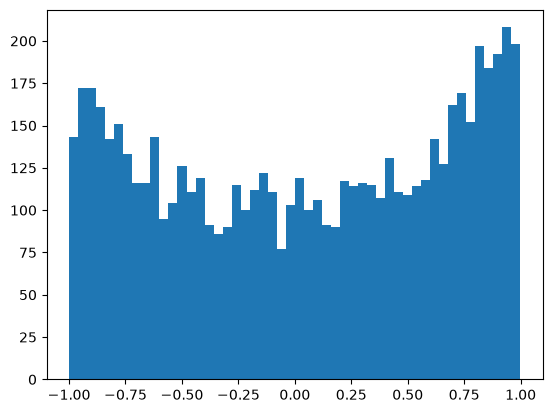

In [32]:
plt.hist(h.view(-1).tolist(),50);

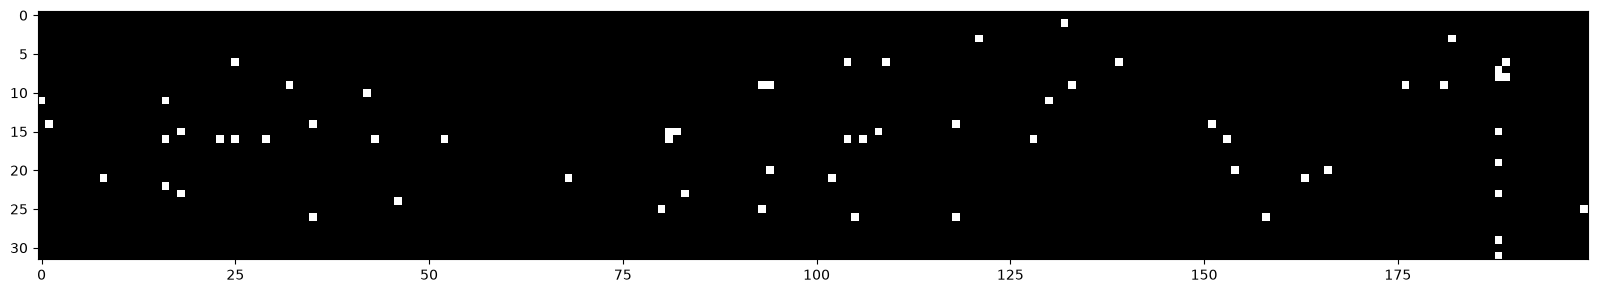

In [33]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')

In [34]:
#可以看到现在之后很少的白点了，而且h的分布比较均匀了

In [35]:
#现在来完整训练
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*0.2      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.3135
  10000/ 200000:2.1648
  20000/ 200000:2.3061
  30000/ 200000:2.4541
  40000/ 200000:1.9787
  50000/ 200000:2.2930
  60000/ 200000:2.4232
  70000/ 200000:2.0680
  80000/ 200000:2.3095
  90000/ 200000:2.1207
 100000/ 200000:1.8269
 110000/ 200000:2.2045
 120000/ 200000:1.9797
 130000/ 200000:2.3946
 140000/ 200000:2.1000
 150000/ 200000:2.1948
 160000/ 200000:1.8619
 170000/ 200000:1.7809
 180000/ 200000:1.9673
 190000/ 200000:1.8295


In [36]:
#重新评估一下
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0355966091156006
val 2.1026782989501953


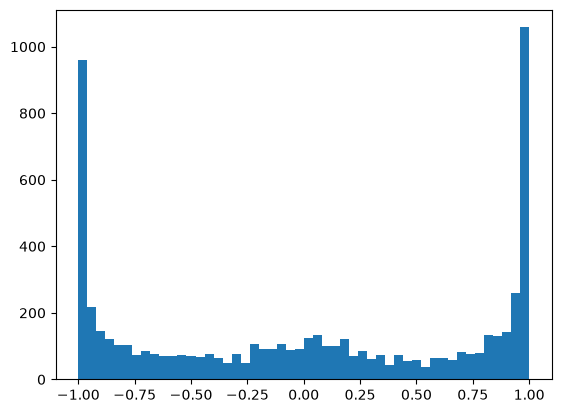

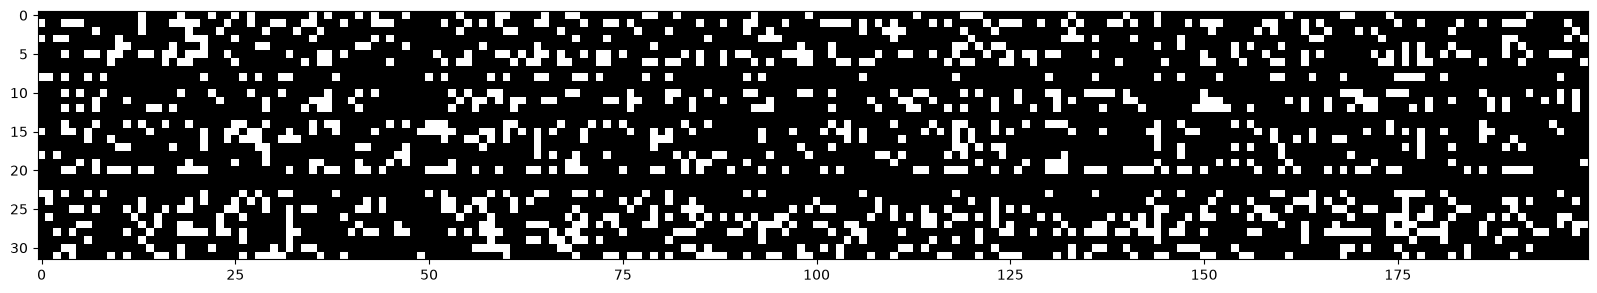

In [37]:
#可以看到loss又下降了一点
#我们看看训练后的h长什么样
plt.hist(h.view(-1).tolist(),50);
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')

In [38]:
#可以看到还是会有有的h会损伤，但是明显比之前初始化时候出现的大片白色好多了
#可能有同学会觉得我们的优化非常简单，但事实上是因为我们的模型非常简单，导致一开始这些问题就不是很严重
#那我们现在来试试看我们上次写的那个多层的模型

总参数量：180707
训练进度：      0/ 100000():3.6852
训练进度：  10000/ 100000():2.3639
训练进度：  20000/ 100000():1.7089
训练进度：  30000/ 100000():2.0761
训练进度：  40000/ 100000():2.0639
训练进度：  50000/ 100000():1.9774
训练进度：  60000/ 100000():2.0746
训练进度：  70000/ 100000():2.1966
训练进度：  80000/ 100000():1.7701
训练进度：  90000/ 100000():1.9708
训练集loss=1.9846832752227783
验证集loss=2.092439889907837


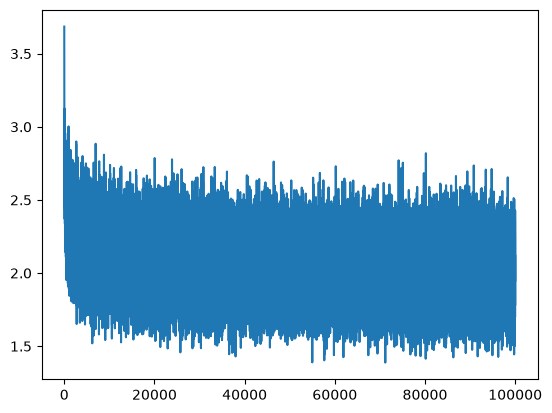

In [39]:
#训练成功
#但是loss不是太低，有很多种方面的原因
#同学可以自己试试看，调一调参数

#固定参数
vocab_size=27
g = torch.Generator().manual_seed(2147483647)

#旋钮
block_size=3
n_embd=40
n_steps=100000
batch_size=50
lr=0.03
layer_size=[block_size*n_embd,800,100,vocab_size]

Ws=[]
bs=[]

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层

#神经网络层
for n1,n2 in zip(layer_size[:-1],layer_size[1:]):
    Ws.append(torch.randn((n1,n2), generator=g)*0.1)#优化一下
    bs.append(torch.randn(n2,generator=g)*0.01)
    
parameters = [C]+Ws+bs#所有的总参数，用于后续的梯度清除

print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#构建数据集
def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

#绘图参数
stepi=[]
lossi=[]

#训练
for i in range(n_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    emb = C[Xtr[ix]] 
    x = emb.view(-1, block_size * n_embd)
    for W, b in zip(Ws[:-1], bs[:-1]):
        x = torch.tanh(x @ W + b)     
    logits = x @ Ws[-1] + bs[-1]                    
    loss=F.cross_entropy(logits,Ytr[ix])
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    for p in parameters:
        p.data+=-lr*p.grad

    #存储参数
    stepi.append(i)
    lossi.append(loss.item())

    if i%10000==0:
        print(f"训练进度：{i:7d}/{n_steps:7d}():{loss.item():.4f}")

emb = C[Xtr] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]               
loss=F.cross_entropy(logits,Ytr)
print(f"训练集loss={loss.item()}")


emb = C[Xdev] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]                  
loss=F.cross_entropy(logits,Ydev)
print(f"验证集loss={loss.item()}")

plt.plot(stepi,lossi)

In [40]:
#是不是非常厉害！我们之前只能到2.2左右，现在直接降到了2以下！

In [41]:
#但是我们刚刚的调试就像我们一开始去创建这个神经网络一样：纯手动，没有什么系统性
#那么怎么系统性的去优化我们的神经网络呢？
#首先，我们要分析清楚：为什么我们会出现刚刚的问题？

tensor(-0.0129) tensor(1.0058)
tensor(0.0012) tensor(3.1506)


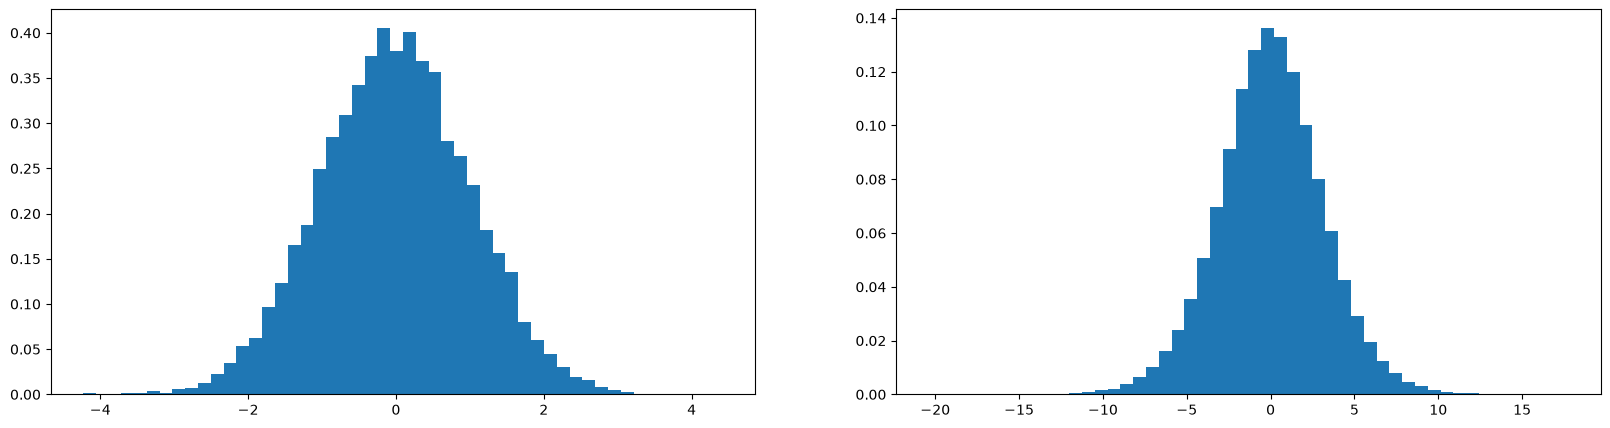

In [42]:
x=torch.randn(1000,10)
w=torch.randn(10,200)
#randn函数会生成符合高斯分布的随机数，也就是标准正态分布，均值0，标准差1
y=x@w
print(x.mean(),x.std())#std是标准差
print(y.mean(),y.std())

plt.figure(figsize=(20, 5))#创建画布，宽 20，高 5
plt.subplot(121)#1 行 2 列，第 1 个子图
plt.hist(x.view(-1).tolist(), 50, density=True);#绘制概率密度分布
plt.subplot(122)#1 行 2 列，第 2 个子图
plt.hist(y.view(-1).tolist(), 50, density=True);

tensor(0.0385) tensor(0.9704)
tensor(-0.0002) tensor(0.9982)


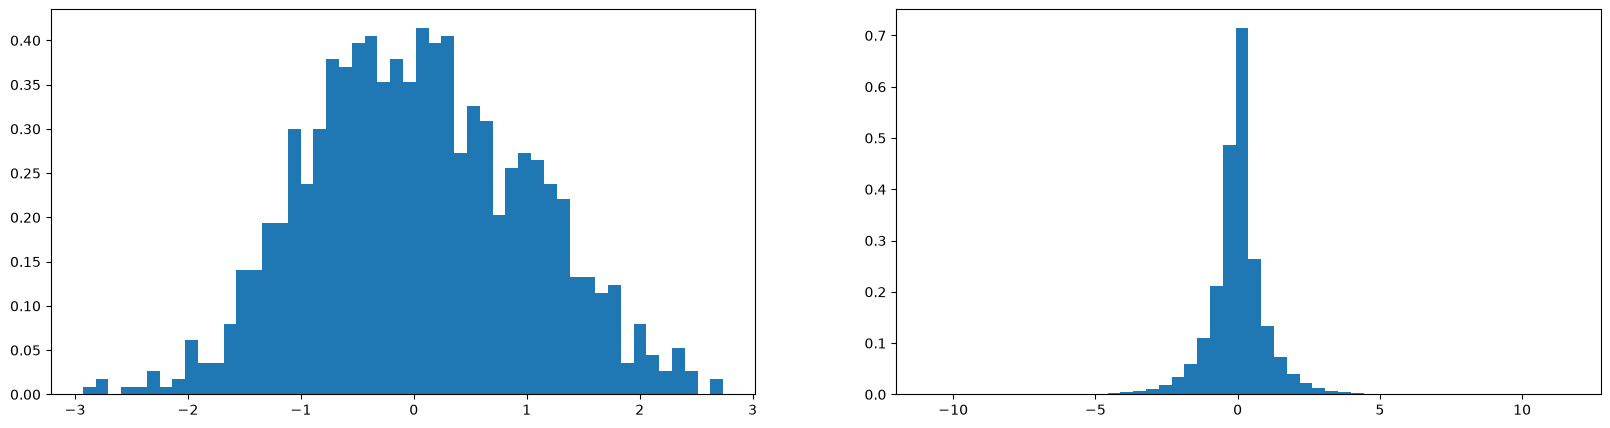

In [43]:
#我们可以发现一件事：乘积之后y的均值变化不大，但是标准差明显变大了，这就是我们的算法里多次累乘累加会导致的问题：出现大值变量
#这里的关键问题是：我们是矩阵乘法，矩阵乘法会导致其中产生加法

x=torch.randn(1000,1)
w=torch.randn(1,1000)
#randn函数会生成符合高斯分布的随机数，也就是标准正态分布，均值0，标准差1
y=x@w
print(x.mean(),x.std())#std是标准差
print(y.mean(),y.std())

plt.figure(figsize=(20, 5))#创建画布，宽 20，高 5
plt.subplot(121)#1 行 2 列，第 1 个子图
plt.hist(x.view(-1).tolist(), 50, density=True);#绘制概率密度分布
plt.subplot(122)#1 行 2 列，第 2 个子图
plt.hist(y.view(-1).tolist(), 50, density=True);

tensor(-0.0108) tensor(1.0034)
tensor(0.0023) tensor(0.9847)


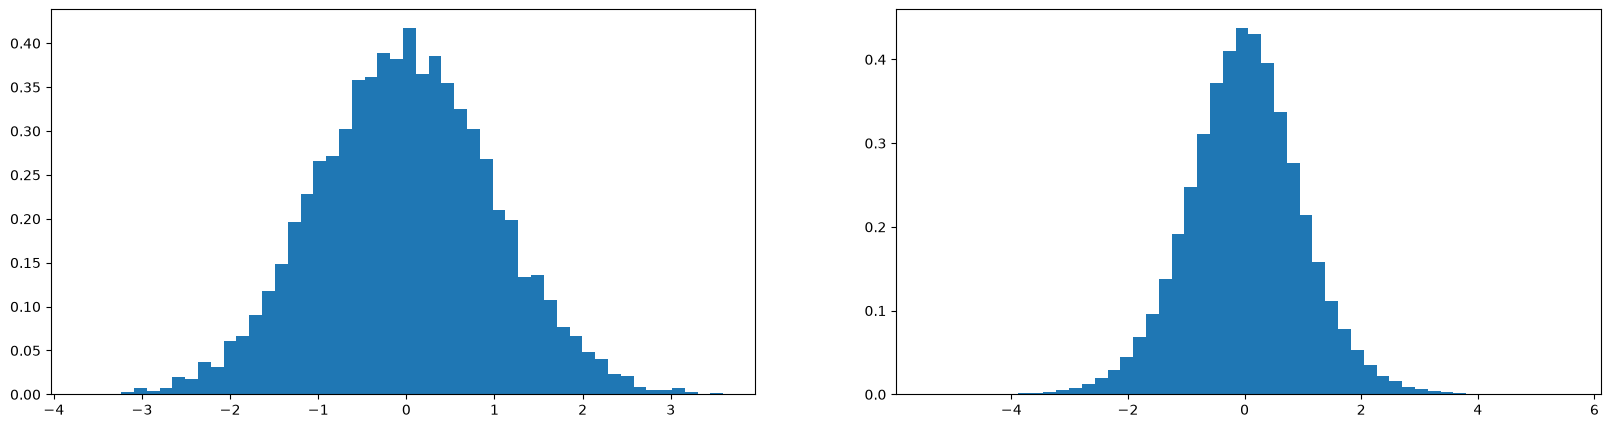

In [44]:
#这样就会发现好了非常多，因为x和w的形状是一列和一行，y的每一个元素都是一个单独的元素乘一个单独的元素
#并且我们可以发现：高斯分布的一个数乘上高斯分布的一个数出来的结果的标准差不会变
#但是我们现在需要十个数相乘之后加起来标准差还不变
#所以根据数学规则：我们需要在这个基础上去除以√10
x=torch.randn(1000,10)
w=torch.randn(10,200)/(10**0.5)
#randn函数会生成符合高斯分布的随机数，也就是标准正态分布，均值0，标准差1
y=x@w
print(x.mean(),x.std())#std是标准差
print(y.mean(),y.std())

plt.figure(figsize=(20, 5))#创建画布，宽 20，高 5
plt.subplot(121)#1 行 2 列，第 1 个子图
plt.hist(x.view(-1).tolist(), 50, density=True);#绘制概率密度分布
plt.subplot(122)#1 行 2 列，第 2 个子图
plt.hist(y.view(-1).tolist(), 50, density=True);

In [45]:
#！！！注意：刚刚出现的所有的y，都已经不是高斯分布了
#因为高斯分布的乘法不具有封闭性
#所以这里虽然看着图像还有点像高斯分布但是其实已经不是高斯分布了

In [46]:
#现在我们手动优化了这个y，但是面对非常复杂的神经网络我们怎么去优化呢？
#何恺明团队给出了一篇非常经典的论文
#《Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification》
#这篇论文有两个重要的贡献
#第一个是关于压缩函数的
#第二个是就是关于参数初始化的
#kaiming提出了要采用零均值高斯分布
#论文原文比较复杂
#但好在这个初始化方法已经被pytorch给集成进来了
#torch.nn.init.kaiming_normal_()就可以初始化了

In [47]:
#何恺明的论文里提出了的初始化方式的作用是：让神经元的信号在传输的时候不会越来越大也不会越来越小
#比如我们刚刚的/(10**0.5)，就是在保证信号传输的时候不会越来越大
#何恺明还提出了一个变量是gain
#是因为激活函数有时候会对变量进行压缩
#代表性的就是tanh和ReLU
#这两个函数都会对把线性层的输出进行数值上的压缩
#所以我们需要去放大一点
#这一来一回一大一小，就出现了两个变量
#一中和，就可以保证神经网络不会越传越大也不会越传越小

#对于tanh函数，gain=5/3

In [ ]:
#所以现在我们把这个代入到之前的东西里
#现在来完整训练
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除 
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.3129
  10000/ 200000:2.4228
  20000/ 200000:2.3509
  30000/ 200000:2.0158
  40000/ 200000:2.0766
  50000/ 200000:2.3837
  60000/ 200000:2.2647
  70000/ 200000:2.0855
  80000/ 200000:1.9400
  90000/ 200000:2.0193
 100000/ 200000:2.4169


In [ ]:
#重新评估一下
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


In [ ]:
#loss差不多
#主要是因为我们的神经网络太简单了
#一旦规模逐渐大起来了，这里的参数就会非常有用